# Notebook 05 — Predicción de Churn: XGBoost + SHAP

**Dataset:** customer_360.parquet (generado en NB03)  
**Objetivo:** Predecir qué clientes tienen alta probabilidad de churn (P_alive < 0.5) usando features RFM + BG/NBD

---
### Pipeline
1. Definición de churn y construcción del dataset
2. Análisis exploratorio de features
3. Preprocesamiento y train/test split
4. Baseline: Logistic Regression
5. Modelo principal: XGBoost con CV y tuning
6. Evaluación: ROC-AUC, PR-AUC, matriz de confusión
7. Interpretabilidad: SHAP values
8. Segmentación de riesgo y acciones de negocio
9. Exportar modelo y predicciones

## 0 · Setup

In [1]:
import os
from pathlib import Path

notebook_dir = Path.cwd()
if notebook_dir.name == 'notebooks':
    os.chdir(notebook_dir.parent)
print('Working directory:', Path.cwd())

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve

# ── XGBoost ───────────────────────────────────────────────────────────────────
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('⚠️  XGBoost no instalado. Ejecuta: pip install xgboost')

# ── SHAP ──────────────────────────────────────────────────────────────────────
try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print('⚠️  SHAP no instalado. Ejecuta: pip install shap')

# ── Estilo visual ─────────────────────────────────────────────────────────────
PALETTE = {
    'primary':   '#2563EB',
    'secondary': '#7C3AED',
    'success':   '#10B981',
    'danger':    '#EF4444',
    'warning':   '#F59E0B',
    'neutral':   '#6B7280',
}
sns.set_theme(style='whitegrid', font='DejaVu Sans')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

DATA_DIR   = Path('data/processed')
OUTPUT_DIR = Path('outputs/05_churn')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
print('✅ Setup completo.')

Working directory: c:\Users\esthe\Desktop\Repository\customer-decision-intelligence
✅ Setup completo.


## 1 · Carga y definición de churn

In [2]:
c360 = pd.read_parquet(DATA_DIR / 'customer_360.parquet')
print(f'Clientes: {len(c360):,} | Columnas: {list(c360.columns)}')
c360.head(3)

Clientes: 5,862 | Columnas: ['Customer ID', 'frequency', 'monetary', 'n_items', 'avg_order_value', 'recency', 'R_score', 'F_score', 'M_score', 'RFM_score', 'RFM_total', 'RFM_segment', 'cluster', 'cluster_label', 'p_alive', 'pred_purchases_4w', 'pred_purchases_12w', 'pred_purchases_26w', 'pred_purchases_52w', 'exp_avg_revenue', 'clv_12m']


,Customer ID,frequency,monetary,n_items,avg_order_value,recency,R_score,F_score,M_score,RFM_score,...,RFM_segment,cluster,cluster_label,p_alive,pred_purchases_4w,pred_purchases_12w,pred_purchases_26w,pred_purchases_52w,exp_avg_revenue,clv_12m
0,12346.0,12,77556.46,74285,6463.038333,326,2,5,5,255,...,At Risk,0,Champions,0.619123,0.024041,0.072095,0.15610,0.311811,11083.867277,3250.396805
1,12347.0,8,5633.32,3286,704.165000,2,5,4,5,545,...,Champions,0,Champions,0.989218,0.064713,0.194011,0.41988,0.838037,720.083105,567.559783
2,12348.0,5,1658.40,2704,331.680000,75,3,4,4,344,...,Loyal,0,Champions,0.963319,0.035768,0.107235,0.23209,0.463270,363.131213,158.220240


In [3]:
# ── Definición de churn ───────────────────────────────────────────────────────
# Usamos P_alive < 0.5 como proxy de churn si está disponible (BG/NBD)
# Fallback: recency > percentil 75 AND frequency == 1 (comprador único inactivo)

if 'p_alive' in c360.columns:
    # Eliminar NaN en p_alive (clientes sin historial de repetición)
    df = c360.dropna(subset=['p_alive']).copy()
    df['churn'] = (df['p_alive'] < 0.5).astype(int)
    CHURN_DEFINITION = 'BG/NBD: P_alive < 0.5'
else:
    # Fallback sin BG/NBD
    df = c360.copy()
    recency_threshold = df['recency'].quantile(0.75)
    df['churn'] = ((df['recency'] > recency_threshold) & (df['frequency'] <= 1)).astype(int)
    CHURN_DEFINITION = f'Heurístico: recency > {recency_threshold:.0f} días AND frequency <= 1'

churn_rate = df['churn'].mean() * 100
print(f'Definición de churn: {CHURN_DEFINITION}')
print(f'Clientes en dataset: {len(df):,}')
print(f'Churn = 1 (inactivos): {df["churn"].sum():,} ({churn_rate:.1f}%)')
print(f'Churn = 0 (activos):   {(df["churn"]==0).sum():,} ({100-churn_rate:.1f}%)')

Definición de churn: BG/NBD: P_alive < 0.5
Clientes en dataset: 5,862
Churn = 1 (inactivos): 296 (5.0%)
Churn = 0 (activos):   5,566 (95.0%)


## 2 · Feature engineering

In [4]:
# ── Features disponibles ──────────────────────────────────────────────────────
BASE_FEATURES = ['recency', 'frequency', 'monetary', 'avg_order_value']
EXTRA_FEATURES = []

# Añadir features de scoring RFM si existen
for col in ['R_score', 'F_score', 'M_score', 'RFM_total']:
    if col in df.columns:
        EXTRA_FEATURES.append(col)

# Añadir predicciones BG/NBD como features si existen
for col in ['pred_purchases_4w', 'pred_purchases_12w', 'pred_purchases_26w', 'pred_purchases_52w']:
    if col in df.columns:
        EXTRA_FEATURES.append(col)

# n_items si existe
if 'n_items' in df.columns:
    EXTRA_FEATURES.append('n_items')

ALL_FEATURES = BASE_FEATURES + EXTRA_FEATURES
print(f'Features base: {BASE_FEATURES}')
print(f'Features extra: {EXTRA_FEATURES}')
print(f'Total features: {len(ALL_FEATURES)}')

# ── Features derivadas ────────────────────────────────────────────────────────
df['log_recency']   = np.log1p(df['recency'])
df['log_frequency'] = np.log1p(df['frequency'])
df['log_monetary']  = np.log1p(df['monetary'])
df['log_aov']       = np.log1p(df['avg_order_value'])
df['revenue_per_day'] = df['monetary'] / (df['recency'] + 1)
df['freq_per_day']    = df['frequency'] / (df['recency'] + 1)

LOG_FEATURES = ['log_recency', 'log_frequency', 'log_monetary', 'log_aov',
                'revenue_per_day', 'freq_per_day']

FINAL_FEATURES = ALL_FEATURES + LOG_FEATURES
# Filtrar solo las que existen
FINAL_FEATURES = [f for f in FINAL_FEATURES if f in df.columns]

print(f'\nFeatures finales para el modelo: {FINAL_FEATURES}')

Features base: ['recency', 'frequency', 'monetary', 'avg_order_value']
Features extra: ['R_score', 'F_score', 'M_score', 'RFM_total', 'pred_purchases_4w', 'pred_purchases_12w', 'pred_purchases_26w', 'pred_purchases_52w', 'n_items']
Total features: 13

Features finales para el modelo: ['recency', 'frequency', 'monetary', 'avg_order_value', 'R_score', 'F_score', 'M_score', 'RFM_total', 'pred_purchases_4w', 'pred_purchases_12w', 'pred_purchases_26w', 'pred_purchases_52w', 'n_items', 'log_recency', 'log_frequency', 'log_monetary', 'log_aov', 'revenue_per_day', 'freq_per_day']


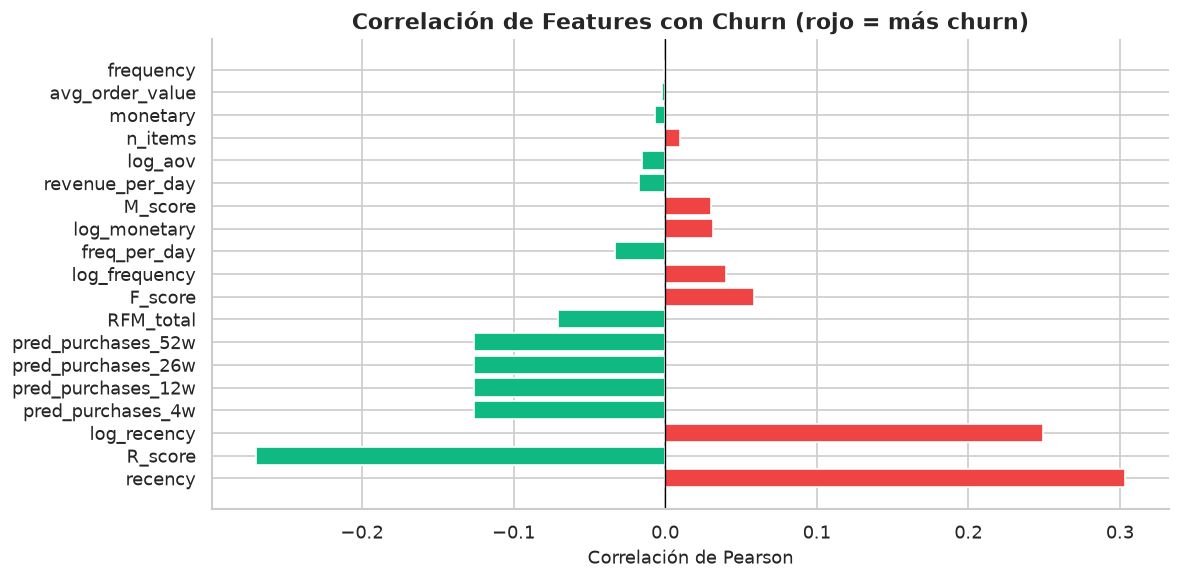

In [5]:
# ── Correlación de features con churn ─────────────────────────────────────────
corr_with_churn = (
    df[FINAL_FEATURES + ['churn']]
    .corr()['churn']
    .drop('churn')
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
colors = [PALETTE['danger'] if v > 0 else PALETTE['success'] for v in corr_with_churn.values]
ax.barh(corr_with_churn.index, corr_with_churn.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlación de Features con Churn (rojo = más churn)', fontweight='bold')
ax.set_xlabel('Correlación de Pearson')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_correlation_churn.png', bbox_inches='tight')
plt.show()

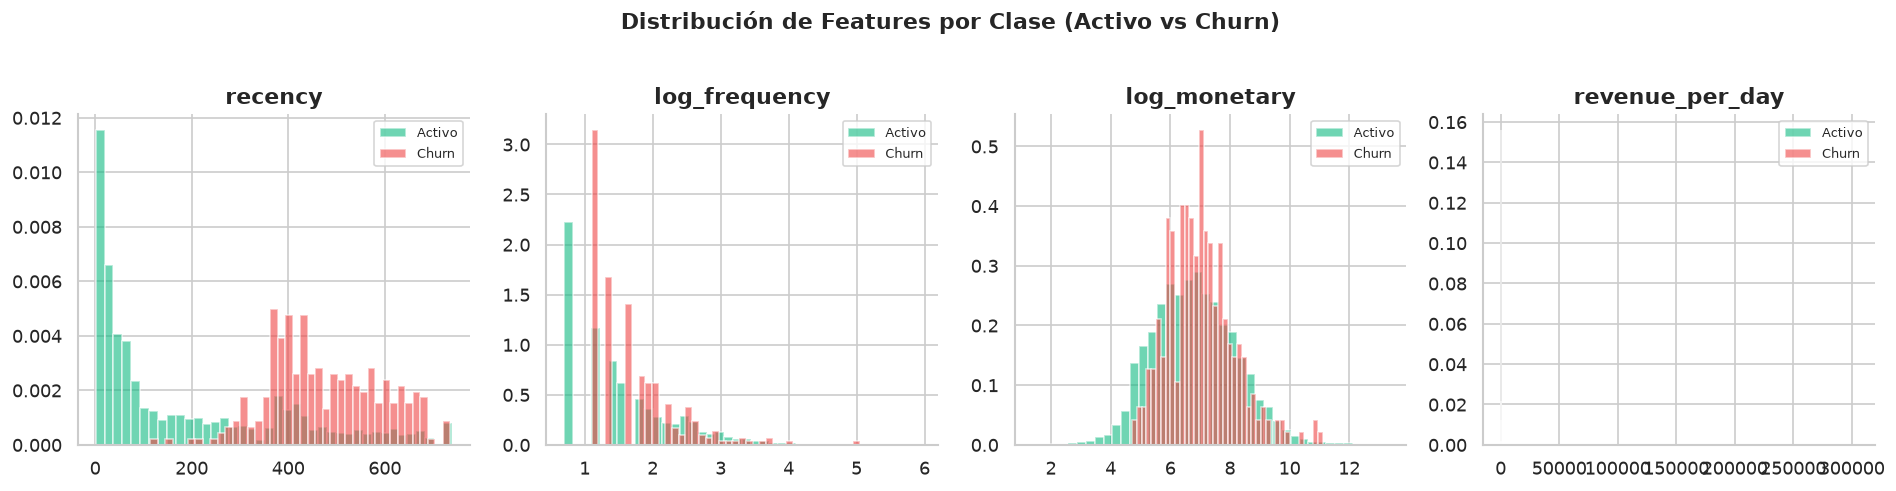

In [6]:
# ── Distribuciones de features clave por clase ────────────────────────────────
key_features = ['recency', 'log_frequency', 'log_monetary', 'revenue_per_day']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, feat in zip(axes, key_features):
    for label, color, name in [(0, PALETTE['success'], 'Activo'), (1, PALETTE['danger'], 'Churn')]:
        data = df.loc[df['churn'] == label, feat].dropna()
        ax.hist(data, bins=40, alpha=0.6, color=color, label=name, density=True)
    ax.set_title(feat, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Distribución de Features por Clase (Activo vs Churn)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_distributions_by_class.png', bbox_inches='tight')
plt.show()

## 3 · Preprocesamiento y split

In [7]:
# ── Preparar X, y ─────────────────────────────────────────────────────────────
X = df[FINAL_FEATURES].fillna(0)
y = df['churn']

# ── Train / Test split estratificado ──────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')
print(f'Churn rate train: {y_train.mean()*100:.1f}%')
print(f'Churn rate test:  {y_test.mean()*100:.1f}%')

# Peso de clases para manejar desbalanceo
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f'\nScale pos weight (neg/pos): {scale_pos_weight:.2f}')

Train: 4,689 | Test: 1,173
Churn rate train: 5.1%
Churn rate test:  5.0%

Scale pos weight (neg/pos): 18.78


## 4 · Baseline: Logistic Regression

In [8]:
# ── Pipeline con StandardScaler ───────────────────────────────────────────────
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lr_cv_roc = cross_val_score(lr_pipe, X_train, y_train, cv=cv, scoring='roc_auc')
lr_cv_pr  = cross_val_score(lr_pipe, X_train, y_train, cv=cv, scoring='average_precision')

print('── Logistic Regression (CV 5-fold) ────────────────────────')
print(f'ROC-AUC: {lr_cv_roc.mean():.4f} ± {lr_cv_roc.std():.4f}')
print(f'PR-AUC:  {lr_cv_pr.mean():.4f} ± {lr_cv_pr.std():.4f}')

lr_pipe.fit(X_train, y_train)
lr_prob  = lr_pipe.predict_proba(X_test)[:, 1]
lr_roc   = roc_auc_score(y_test, lr_prob)
lr_pr    = average_precision_score(y_test, lr_prob)
print(f'\nTest ROC-AUC: {lr_roc:.4f}')
print(f'Test PR-AUC:  {lr_pr:.4f}')

── Logistic Regression (CV 5-fold) ────────────────────────
ROC-AUC: 0.9846 ± 0.0069
PR-AUC:  0.8279 ± 0.0477

Test ROC-AUC: 0.9856
Test PR-AUC:  0.8099


## 5 · Modelo principal: XGBoost

In [9]:
if not HAS_XGB:
    raise ImportError('Instala XGBoost: pip install xgboost')

# ── Parámetros XGBoost ────────────────────────────────────────────────────────
xgb_params = {
    'n_estimators':       300,
    'max_depth':          4,
    'learning_rate':      0.05,
    'subsample':          0.8,
    'colsample_bytree':   0.8,
    'min_child_weight':   5,
    'gamma':              0.1,
    'reg_alpha':          0.1,
    'reg_lambda':         1.0,
    'scale_pos_weight':   scale_pos_weight,
    'eval_metric':        'auc',
    'use_label_encoder':  False,
    'random_state':       RANDOM_STATE,
    'n_jobs':             -1,
}

xgb = XGBClassifier(**xgb_params)

# ── Cross-validation ──────────────────────────────────────────────────────────
xgb_cv_roc = cross_val_score(xgb, X_train, y_train, cv=cv, scoring='roc_auc')
xgb_cv_pr  = cross_val_score(xgb, X_train, y_train, cv=cv, scoring='average_precision')

print('── XGBoost (CV 5-fold) ─────────────────────────────────────')
print(f'ROC-AUC: {xgb_cv_roc.mean():.4f} ± {xgb_cv_roc.std():.4f}')
print(f'PR-AUC:  {xgb_cv_pr.mean():.4f} ± {xgb_cv_pr.std():.4f}')

# ── Fit final ─────────────────────────────────────────────────────────────────
xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_prob = xgb.predict_proba(X_test)[:, 1]
xgb_roc  = roc_auc_score(y_test, xgb_prob)
xgb_pr   = average_precision_score(y_test, xgb_prob)

print(f'\nTest ROC-AUC: {xgb_roc:.4f}')
print(f'Test PR-AUC:  {xgb_pr:.4f}')
print(f'\nMejora vs Logistic Regression:')
print(f'  ROC-AUC: +{(xgb_roc - lr_roc)*100:.2f}pp')
print(f'  PR-AUC:  +{(xgb_pr  - lr_pr )*100:.2f}pp')

── XGBoost (CV 5-fold) ─────────────────────────────────────
ROC-AUC: 0.9924 ± 0.0039
PR-AUC:  0.8950 ± 0.0385

Test ROC-AUC: 0.9910
Test PR-AUC:  0.8266

Mejora vs Logistic Regression:
  ROC-AUC: +0.53pp
  PR-AUC:  +1.67pp


## 6 · Evaluación completa

In [10]:
# ── Umbral óptimo por F1 ──────────────────────────────────────────────────────
prec, rec, thresholds = precision_recall_curve(y_test, xgb_prob)
f1_scores  = 2 * prec * rec / (prec + rec + 1e-9)
best_idx   = np.argmax(f1_scores[:-1])
best_thresh = thresholds[best_idx]
best_f1     = f1_scores[best_idx]

print(f'Umbral óptimo (F1): {best_thresh:.3f} → F1={best_f1:.4f}')

y_pred = (xgb_prob >= best_thresh).astype(int)
print('\n── Classification Report ───────────────────────────────────')
print(classification_report(y_test, y_pred, target_names=['Activo', 'Churn']))

Umbral óptimo (F1): 0.366 → F1=0.8397

── Classification Report ───────────────────────────────────
              precision    recall  f1-score   support

      Activo       1.00      0.98      0.99      1114
       Churn       0.76      0.93      0.84        59

    accuracy                           0.98      1173
   macro avg       0.88      0.96      0.92      1173
weighted avg       0.98      0.98      0.98      1173



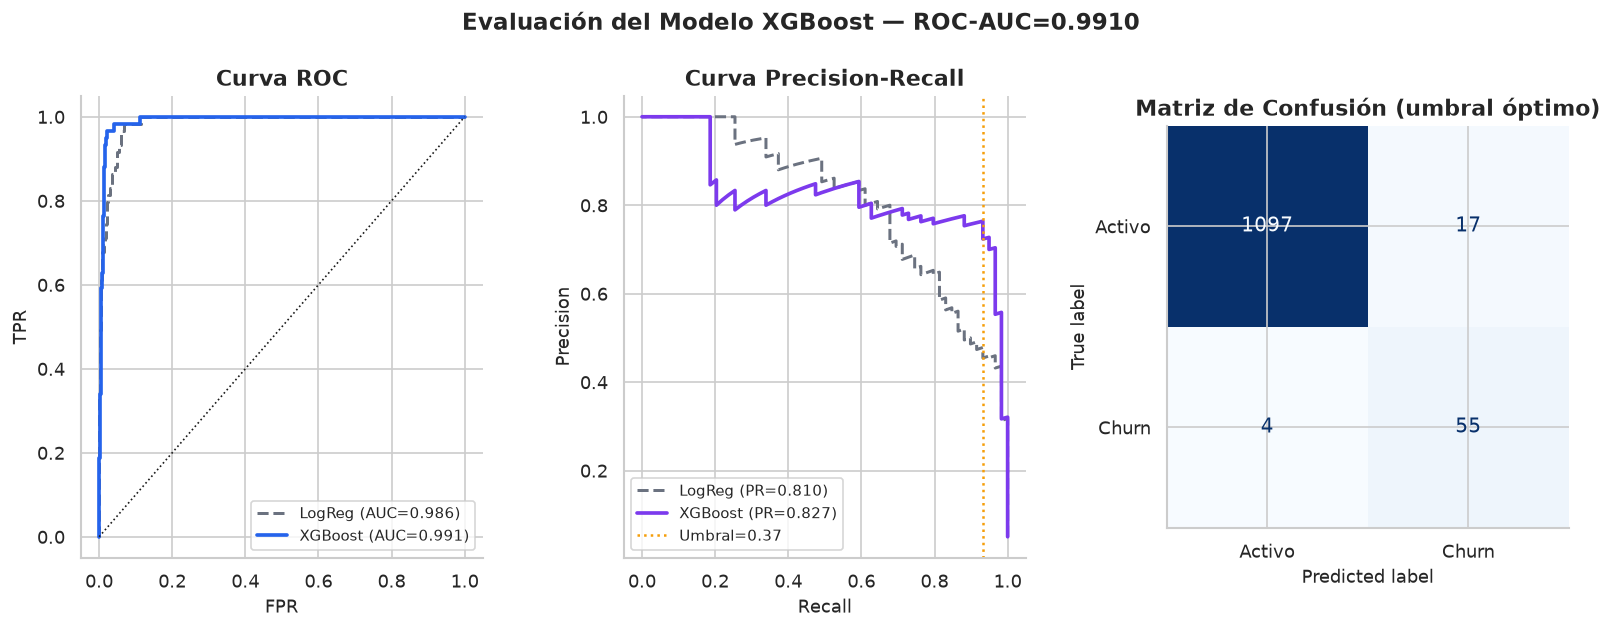

In [11]:
# ── Panel de evaluación ───────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# 1. ROC Curve
ax1 = fig.add_subplot(gs[0])
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
fpr_xg, tpr_xg, _ = roc_curve(y_test, xgb_prob)
ax1.plot(fpr_lr, tpr_lr, '--', color=PALETTE['neutral'],  lw=1.8, label=f'LogReg (AUC={lr_roc:.3f})')
ax1.plot(fpr_xg, tpr_xg,       color=PALETTE['primary'], lw=2.2, label=f'XGBoost (AUC={xgb_roc:.3f})')
ax1.plot([0,1],[0,1], 'k:', lw=1)
ax1.set_title('Curva ROC', fontweight='bold')
ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR')
ax1.legend(fontsize=9)

# 2. Precision-Recall Curve
ax2 = fig.add_subplot(gs[1])
p_lr, r_lr, _ = precision_recall_curve(y_test, lr_prob)
ax2.plot(r_lr, p_lr, '--', color=PALETTE['neutral'],  lw=1.8, label=f'LogReg (PR={lr_pr:.3f})')
ax2.plot(rec,  prec,       color=PALETTE['secondary'], lw=2.2, label=f'XGBoost (PR={xgb_pr:.3f})')
ax2.axvline(rec[best_idx], color=PALETTE['warning'], linestyle=':', lw=1.5, label=f'Umbral={best_thresh:.2f}')
ax2.set_title('Curva Precision-Recall', fontweight='bold')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.legend(fontsize=9)

# 3. Confusion Matrix
ax3 = fig.add_subplot(gs[2])
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Activo','Churn'])
disp.plot(ax=ax3, colorbar=False, cmap='Blues')
ax3.set_title('Matriz de Confusión (umbral óptimo)', fontweight='bold')

plt.suptitle(f'Evaluación del Modelo XGBoost — ROC-AUC={xgb_roc:.4f}', 
             fontsize=14, fontweight='bold', y=1.02)
plt.savefig(OUTPUT_DIR / 'model_evaluation.png', bbox_inches='tight')
plt.show()

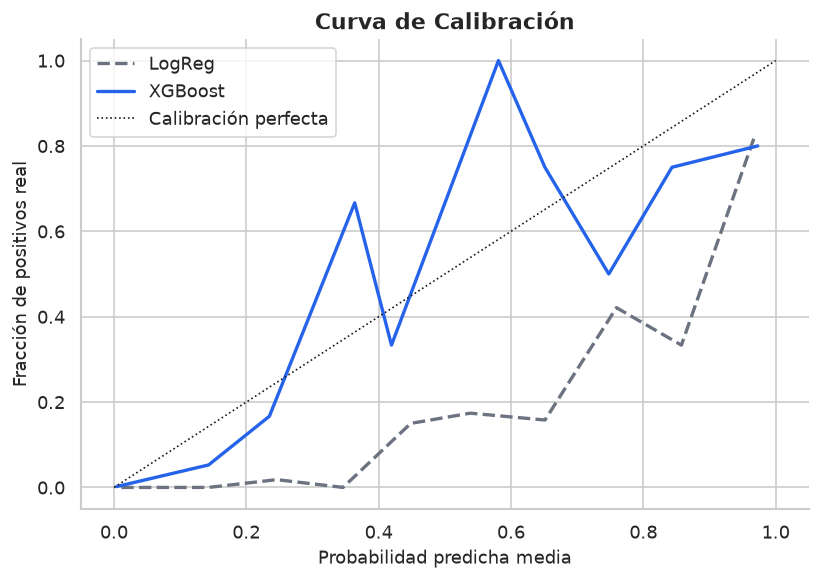

In [12]:
# ── Calibración del modelo ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

for prob, label, color, ls in [
    (lr_prob,  f'LogReg',  PALETTE['neutral'],  '--'),
    (xgb_prob, f'XGBoost', PALETTE['primary'],  '-'),
]:
    frac_pos, mean_pred = calibration_curve(y_test, prob, n_bins=10)
    ax.plot(mean_pred, frac_pos, ls, color=color, lw=2, label=label)

ax.plot([0,1],[0,1], 'k:', lw=1, label='Calibración perfecta')
ax.set_title('Curva de Calibración', fontweight='bold')
ax.set_xlabel('Probabilidad predicha media')
ax.set_ylabel('Fracción de positivos real')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'calibration_curve.png', bbox_inches='tight')
plt.show()

In [13]:
# ── Comparativa de modelos ────────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Modelo':   ['Logistic Regression', 'XGBoost'],
    'CV ROC-AUC (mean)': [lr_cv_roc.mean(), xgb_cv_roc.mean()],
    'CV ROC-AUC (std)':  [lr_cv_roc.std(),  xgb_cv_roc.std()],
    'CV PR-AUC (mean)':  [lr_cv_pr.mean(),  xgb_cv_pr.mean()],
    'Test ROC-AUC':      [lr_roc, xgb_roc],
    'Test PR-AUC':       [lr_pr,  xgb_pr],
}).round(4)

print('── Comparativa de Modelos ──────────────────────────────────')
print(comparison.to_string(index=False))

── Comparativa de Modelos ──────────────────────────────────
             Modelo  CV ROC-AUC (mean)  CV ROC-AUC (std)  CV PR-AUC (mean)  Test ROC-AUC  Test PR-AUC
Logistic Regression             0.9846            0.0069            0.8279        0.9856       0.8099
            XGBoost             0.9924            0.0039            0.8950        0.9910       0.8266


## 7 · Interpretabilidad: SHAP Values

In [14]:
if not HAS_SHAP:
    print('⚠️  SHAP no disponible. Instala con: pip install shap')
else:
    explainer   = shap.TreeExplainer(xgb)
    shap_values = explainer.shap_values(X_test)

    print(f'SHAP values shape: {np.array(shap_values).shape}')
    print('✅ SHAP calculado')

SHAP values shape: (1173, 19)
✅ SHAP calculado


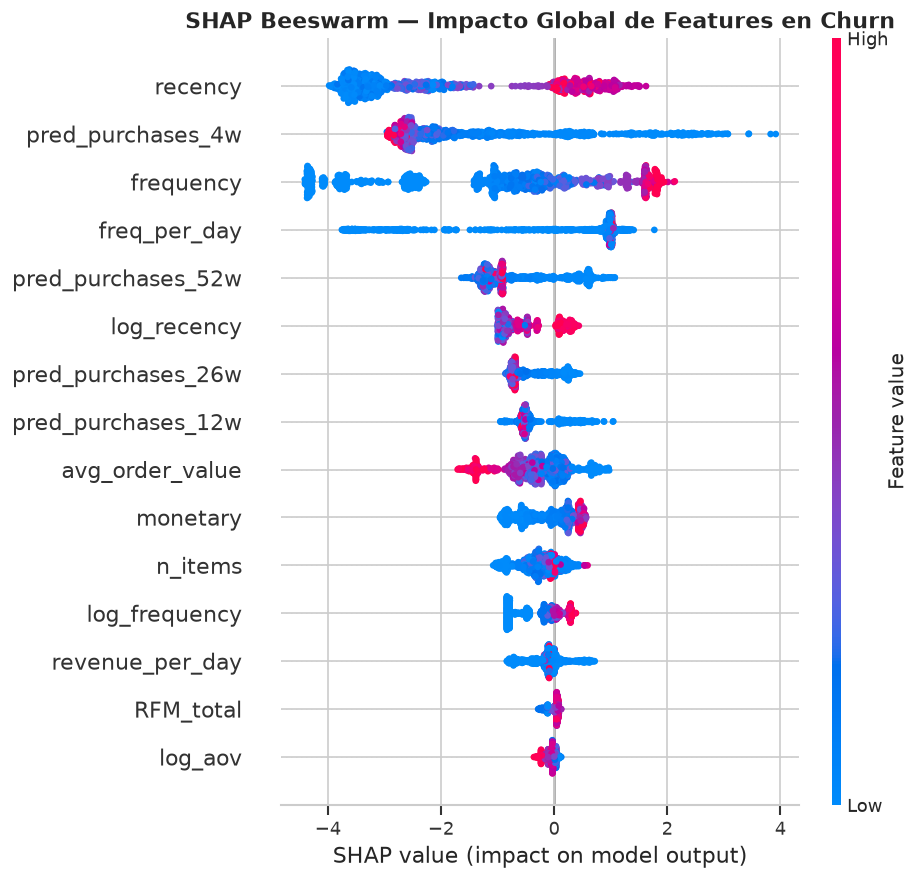

In [15]:
if HAS_SHAP:
    # ── Beeswarm plot (global feature importance) ─────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 7))
    shap.summary_plot(
        shap_values, X_test,
        feature_names=FINAL_FEATURES,
        plot_type='dot',
        show=False,
        max_display=15
    )
    plt.title('SHAP Beeswarm — Impacto Global de Features en Churn', 
              fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'shap_beeswarm.png', bbox_inches='tight')
    plt.show()

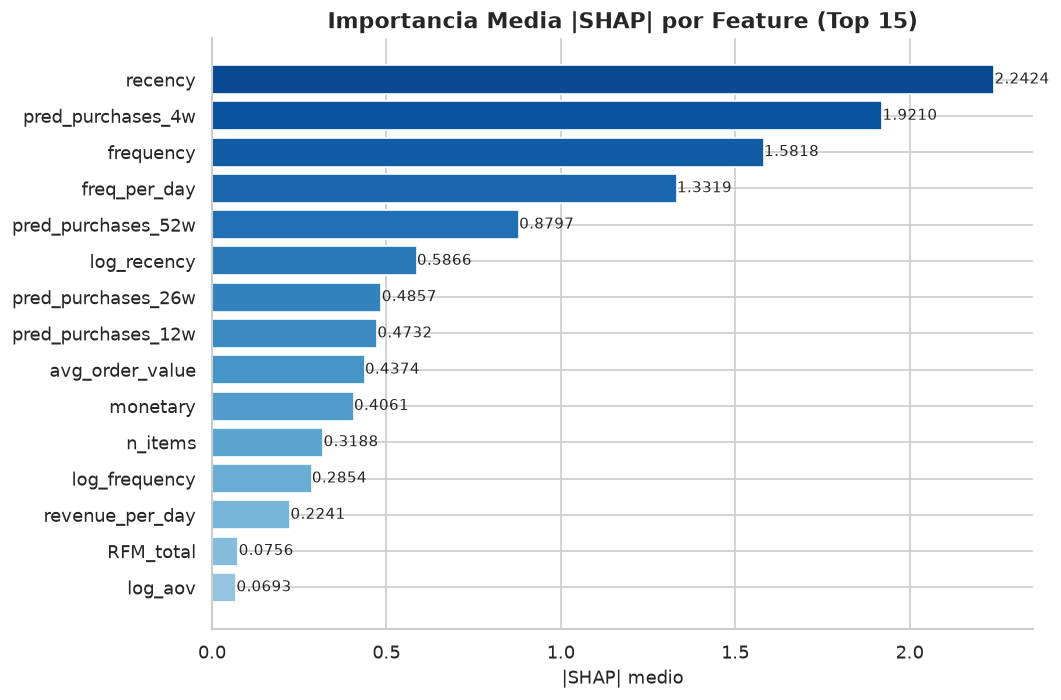

In [16]:
if HAS_SHAP:
    # ── Bar plot (importancia media absoluta) ─────────────────────────────────
    mean_shap = pd.Series(
        np.abs(shap_values).mean(axis=0),
        index=FINAL_FEATURES
    ).sort_values(ascending=True).tail(15)

    fig, ax = plt.subplots(figsize=(9, 6))
    colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(mean_shap)))
    ax.barh(mean_shap.index, mean_shap.values, color=colors, edgecolor='white')
    ax.set_title('Importancia Media |SHAP| por Feature (Top 15)', fontweight='bold')
    ax.set_xlabel('|SHAP| medio')
    for i, v in enumerate(mean_shap.values):
        ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'shap_importance_bar.png', bbox_inches='tight')
    plt.show()

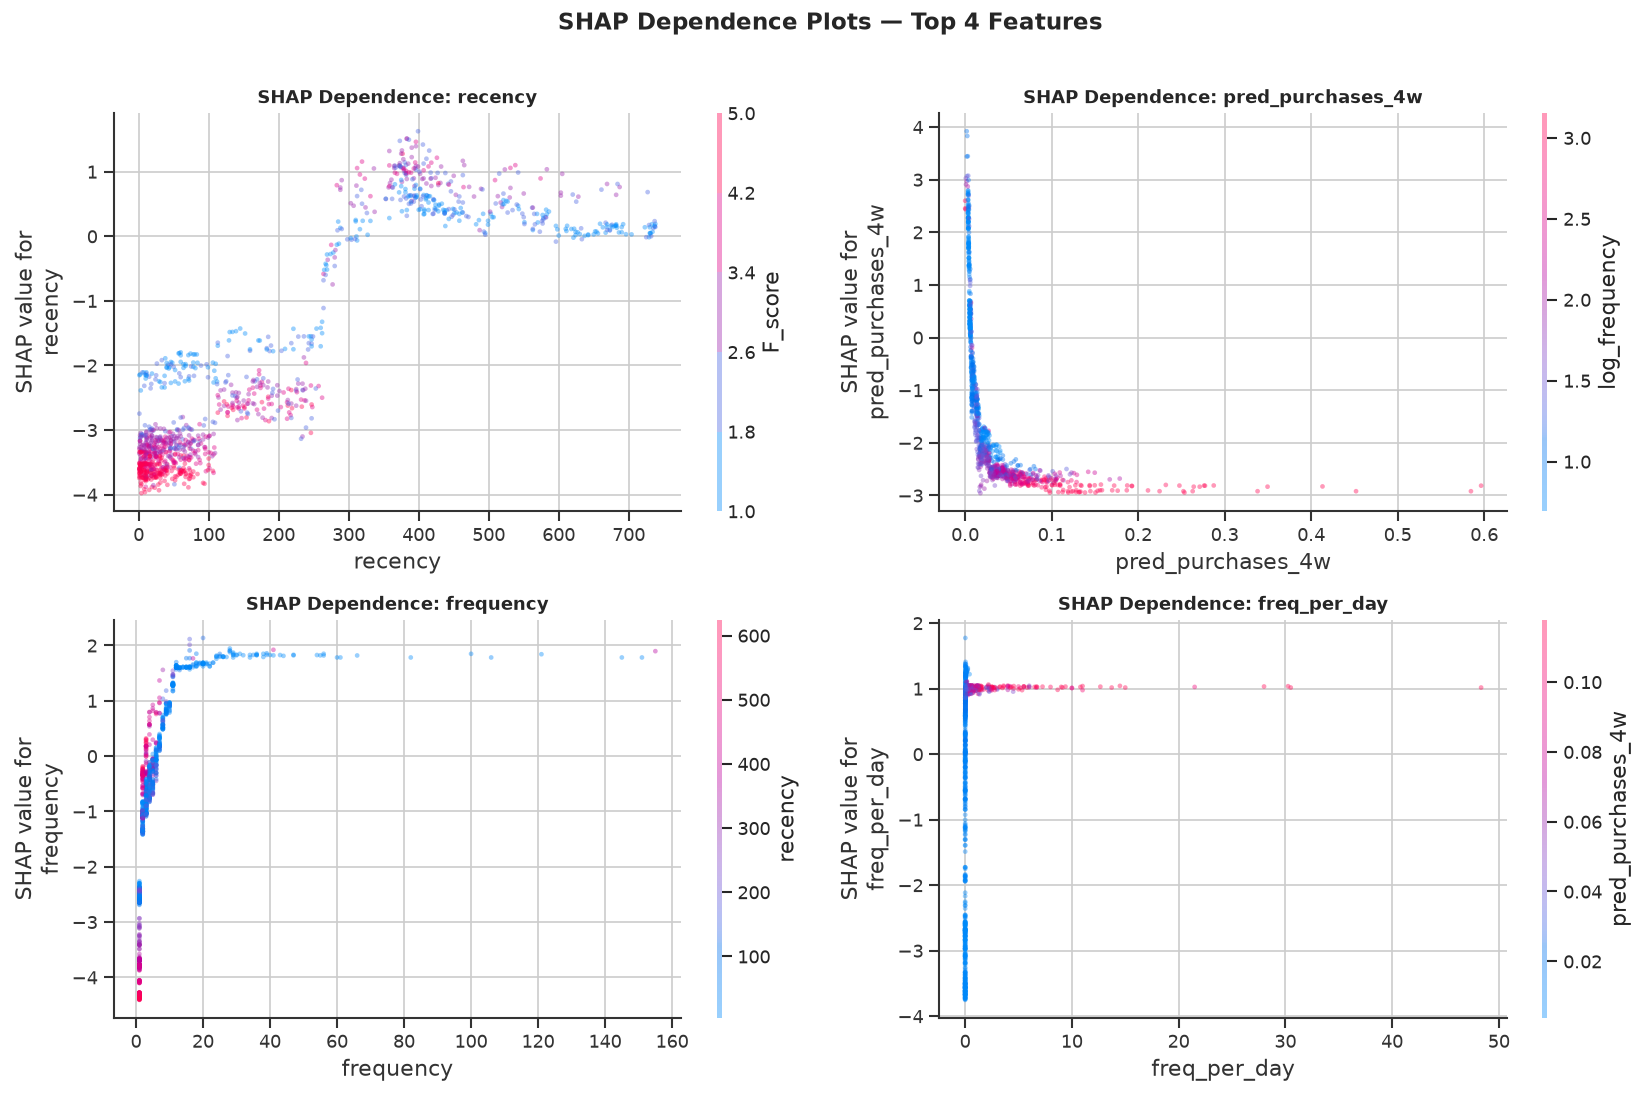

In [17]:
if HAS_SHAP:
    # ── SHAP Dependence plots — Top 4 features ────────────────────────────────
    top4 = pd.Series(
        np.abs(shap_values).mean(axis=0),
        index=FINAL_FEATURES
    ).nlargest(4).index.tolist()

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    axes = axes.flatten()

    for i, feat in enumerate(top4):
        shap.dependence_plot(
            feat, shap_values, X_test,
            feature_names=FINAL_FEATURES,
            ax=axes[i], show=False,
            dot_size=8, alpha=0.4
        )
        axes[i].set_title(f'SHAP Dependence: {feat}', fontweight='bold', fontsize=11)

    plt.suptitle('SHAP Dependence Plots — Top 4 Features', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'shap_dependence_top4.png', bbox_inches='tight')
    plt.show()

Cliente de alto riesgo (índice en test): 836
  Churn probability: 1.0000
  Churn real: 1
  Features:
recency              372.000000
frequency            155.000000
monetary           56600.080000
avg_order_value      365.161806


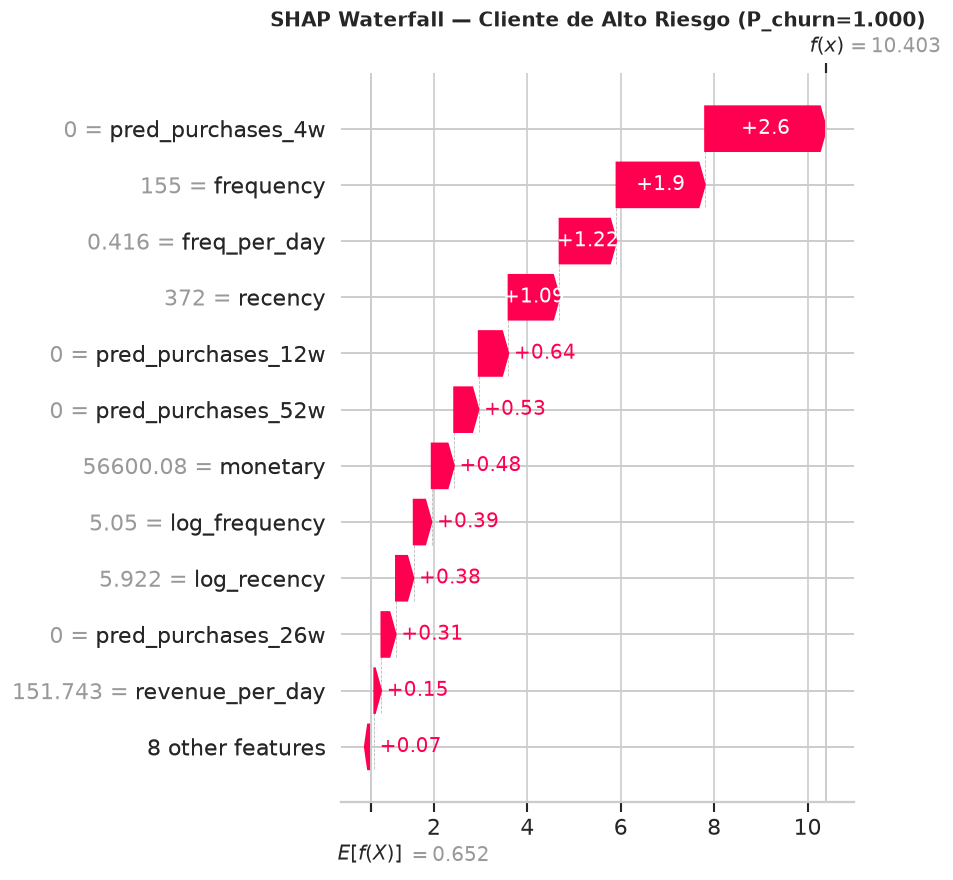

In [18]:
if HAS_SHAP:
    # ── Waterfall para cliente individual (alto riesgo) ───────────────────────
    # Seleccionar el cliente con mayor probabilidad de churn en test
    high_risk_idx = np.argmax(xgb_prob)

    print(f'Cliente de alto riesgo (índice en test): {high_risk_idx}')
    print(f'  Churn probability: {xgb_prob[high_risk_idx]:.4f}')
    print(f'  Churn real: {y_test.iloc[high_risk_idx]}')
    print(f'  Features:')
    print(X_test.iloc[high_risk_idx][['recency','frequency','monetary','avg_order_value']].to_string())

    fig, ax = plt.subplots(figsize=(10, 6))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[high_risk_idx],
            base_values=explainer.expected_value,
            data=X_test.iloc[high_risk_idx].values,
            feature_names=FINAL_FEATURES
        ),
        show=False, max_display=12
    )
    plt.title(f'SHAP Waterfall — Cliente de Alto Riesgo (P_churn={xgb_prob[high_risk_idx]:.3f})',
              fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'shap_waterfall_high_risk.png', bbox_inches='tight')
    plt.show()

## 8 · Segmentación de riesgo y acciones de negocio

In [19]:
# ── Predicciones sobre todo el dataset ───────────────────────────────────────
X_all  = df[FINAL_FEATURES].fillna(0)
df['churn_prob']     = xgb.predict_proba(X_all)[:, 1]
df['churn_pred']     = (df['churn_prob'] >= best_thresh).astype(int)

# ── Segmentos de riesgo ───────────────────────────────────────────────────────
def risk_segment(p):
    if p >= 0.75:   return '🔴 Riesgo Crítico'
    elif p >= 0.50: return '🟠 Alto Riesgo'
    elif p >= 0.25: return '🟡 Riesgo Moderado'
    else:           return '🟢 Bajo Riesgo'

df['risk_segment'] = df['churn_prob'].apply(risk_segment)

risk_summary = (
    df.groupby('risk_segment')
    .agg(
        n_clientes   = ('churn_prob', 'count'),
        revenue_total= ('monetary', 'sum'),
        clv_total    = ('clv_12m', 'sum') if 'clv_12m' in df.columns else ('monetary', 'sum'),
        recency_med  = ('recency', 'median'),
        freq_med     = ('frequency', 'median'),
        prob_media   = ('churn_prob', 'mean'),
    )
    .round(2)
    .sort_values('prob_media', ascending=False)
)

print('── Distribución de Riesgo de Churn ─────────────────────────')
print(risk_summary.to_string())

── Distribución de Riesgo de Churn ─────────────────────────
                   n_clientes  revenue_total   clv_total  recency_med  freq_med  prob_media
risk_segment                                                                               
🔴 Riesgo Crítico          329      866095.44    10930.31        465.0       3.0        0.96
🟠 Alto Riesgo              44       42531.74     1618.72        412.0       3.0        0.64
🟡 Riesgo Moderado          42       64072.43     2460.47        412.5       4.0        0.35
🟢 Bajo Riesgo            5447    16479056.71  1188040.15         78.0       3.0        0.01


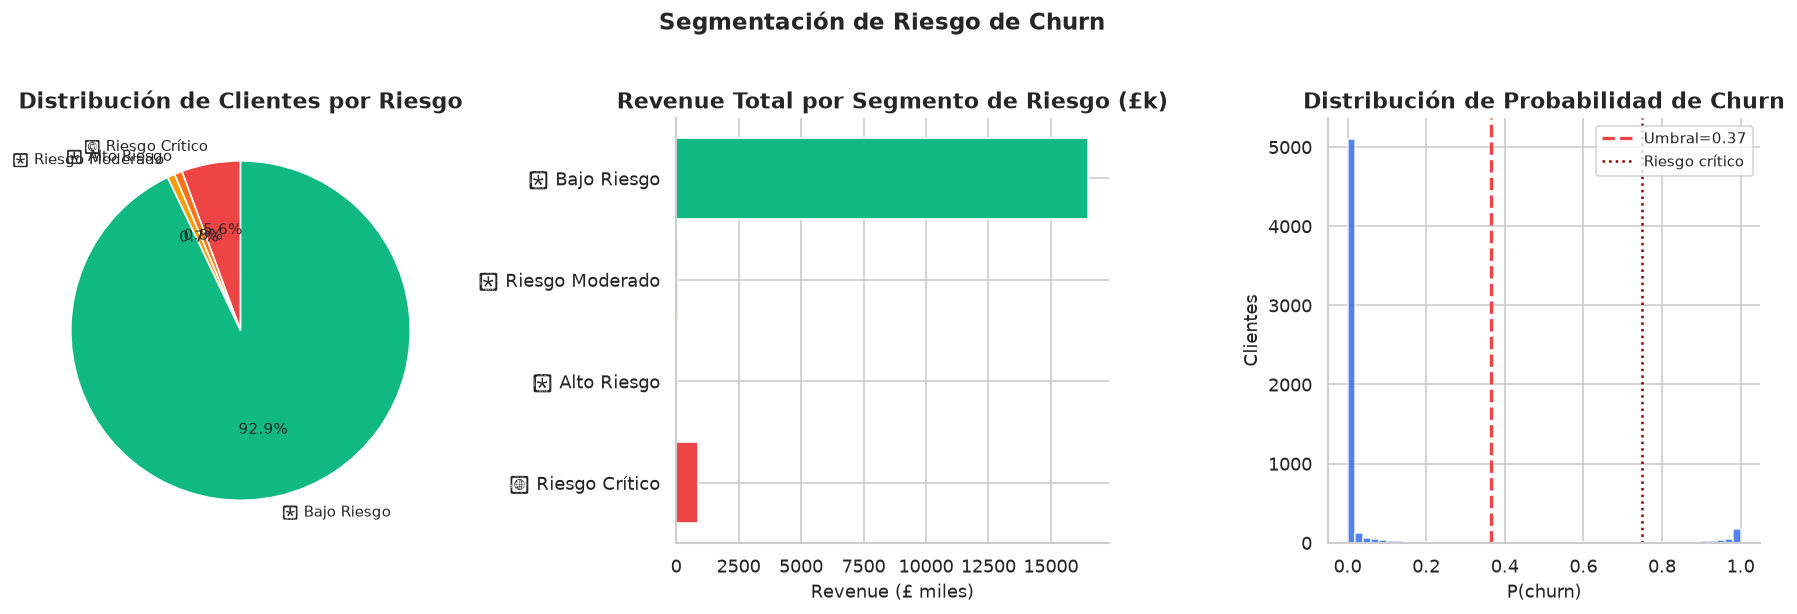

In [20]:
# ── Visualización segmentos de riesgo ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

risk_colors = {
    '🔴 Riesgo Crítico':  '#EF4444',
    '🟠 Alto Riesgo':     '#F97316',
    '🟡 Riesgo Moderado': '#F59E0B',
    '🟢 Bajo Riesgo':     '#10B981',
}

# Distribución de clientes
seg_counts = df['risk_segment'].value_counts().reindex(list(risk_colors.keys())).dropna()
axes[0].pie(
    seg_counts.values,
    labels=seg_counts.index,
    colors=[risk_colors[s] for s in seg_counts.index],
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 9}
)
axes[0].set_title('Distribución de Clientes por Riesgo', fontweight='bold')

# Revenue en riesgo
rev_risk = df.groupby('risk_segment')['monetary'].sum().reindex(list(risk_colors.keys())).dropna()
axes[1].barh(
    rev_risk.index, rev_risk.values / 1e3,
    color=[risk_colors[s] for s in rev_risk.index], edgecolor='white'
)
axes[1].set_title('Revenue Total por Segmento de Riesgo (£k)', fontweight='bold')
axes[1].set_xlabel('Revenue (£ miles)')

# Histograma de probabilidad de churn
axes[2].hist(df['churn_prob'], bins=50, color=PALETTE['primary'], alpha=0.8, edgecolor='white')
axes[2].axvline(best_thresh, color=PALETTE['danger'], linestyle='--', lw=2,
               label=f'Umbral={best_thresh:.2f}')
axes[2].axvline(0.75, color='darkred', linestyle=':', lw=1.5, label='Riesgo crítico')
axes[2].set_title('Distribución de Probabilidad de Churn', fontweight='bold')
axes[2].set_xlabel('P(churn)')
axes[2].set_ylabel('Clientes')
axes[2].legend(fontsize=9)

plt.suptitle('Segmentación de Riesgo de Churn', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'churn_risk_segments.png', bbox_inches='tight')
plt.show()

In [21]:
# ── Acciones recomendadas ─────────────────────────────────────────────────────
print('='*70)
print(' PLAN DE ACCION POR SEGMENTO DE RIESGO')
print('='*70)

actions = [
    ('🔴 Riesgo Crítico',  'P_churn >= 0.75',
     'Campaña win-back urgente: descuento 20-25% + llamada personal.',
     'ROI bajo — priorizar por CLV. Presupuesto máximo por cliente.'),
    ('🟠 Alto Riesgo',     'P_churn 0.50-0.75',
     'Email personalizado con oferta de reactivación + encuesta NPS.',
     'Segmento más tratable. Mayor probabilidad de recuperación.'),
    ('🟡 Riesgo Moderado', 'P_churn 0.25-0.50',
     'Newsletter con productos recomendados basados en historial.',
     'Prevención proactiva. Bajo coste de intervención.'),
    ('🟢 Bajo Riesgo',     'P_churn < 0.25',
     'Programa de fidelización, upsell y cross-sell.',
     'Mantener y maximizar CLV. Son los Champions actuales.'),
]

for seg, criteria, action, rationale in actions:
    n_seg = (df['risk_segment'] == seg).sum()
    rev   = df.loc[df['risk_segment']==seg, 'monetary'].sum()
    if n_seg > 0:
        print(f'\n{seg} ({criteria})')
        print(f'  Clientes: {n_seg:,} | Revenue histórico: £{rev:,.0f}')
        print(f'  Accion:   {action}')
        print(f'  Racional: {rationale}')

print('\n' + '='*70)

 PLAN DE ACCION POR SEGMENTO DE RIESGO

🔴 Riesgo Crítico (P_churn >= 0.75)
  Clientes: 329 | Revenue histórico: £866,095
  Accion:   Campaña win-back urgente: descuento 20-25% + llamada personal.
  Racional: ROI bajo — priorizar por CLV. Presupuesto máximo por cliente.

🟠 Alto Riesgo (P_churn 0.50-0.75)
  Clientes: 44 | Revenue histórico: £42,532
  Accion:   Email personalizado con oferta de reactivación + encuesta NPS.
  Racional: Segmento más tratable. Mayor probabilidad de recuperación.

🟡 Riesgo Moderado (P_churn 0.25-0.50)
  Clientes: 42 | Revenue histórico: £64,072
  Accion:   Newsletter con productos recomendados basados en historial.
  Racional: Prevención proactiva. Bajo coste de intervención.

🟢 Bajo Riesgo (P_churn < 0.25)
  Clientes: 5,447 | Revenue histórico: £16,479,057
  Accion:   Programa de fidelización, upsell y cross-sell.
  Racional: Mantener y maximizar CLV. Son los Champions actuales.



## 9 · Exportar modelo y predicciones

In [22]:
# ── Guardar modelo XGBoost ────────────────────────────────────────────────────
xgb.save_model(str(OUTPUT_DIR / 'xgb_churn_model.json'))
print('✅ xgb_churn_model.json guardado')

# ── Guardar pipeline Logistic Regression ──────────────────────────────────────
joblib.dump(lr_pipe, OUTPUT_DIR / 'lr_baseline.joblib')
print('✅ lr_baseline.joblib guardado')

# ── Guardar metadata del modelo ───────────────────────────────────────────────
import json
model_meta = {
    'features':        FINAL_FEATURES,
    'churn_definition': CHURN_DEFINITION,
    'optimal_threshold': float(best_thresh),
    'test_roc_auc':    float(xgb_roc),
    'test_pr_auc':     float(xgb_pr),
    'test_f1':         float(best_f1),
    'cv_roc_auc_mean': float(xgb_cv_roc.mean()),
    'cv_roc_auc_std':  float(xgb_cv_roc.std()),
    'n_train':         len(X_train),
    'n_test':          len(X_test),
    'churn_rate':      float(churn_rate),
}
with open(OUTPUT_DIR / 'model_metadata.json', 'w') as f:
    json.dump(model_meta, f, indent=2)
print('✅ model_metadata.json guardado')

# ── Guardar predicciones completas ────────────────────────────────────────────
cols_export = ['Customer ID'] if 'Customer ID' in df.columns else []
for c in ['cluster_label','RFM_segment','recency','frequency','monetary',
          'avg_order_value','p_alive','clv_12m','churn','churn_prob','churn_pred','risk_segment']:
    if c in df.columns:
        cols_export.append(c)

churn_predictions = df[cols_export].copy()
churn_predictions.to_parquet(DATA_DIR / 'churn_predictions.parquet', index=False)
churn_predictions.to_csv(OUTPUT_DIR / 'churn_predictions.csv', index=False)
print(f'✅ churn_predictions.parquet + .csv guardados ({len(churn_predictions):,} clientes)')

# ── Resumen final ─────────────────────────────────────────────────────────────
print('\n📦 Archivos generados en outputs/05_churn/:')
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f'   {f.name:<45} {f.stat().st_size/1024:>7.1f} KB')

print('\n✅ Notebook 05 completado.')
print(f'   ROC-AUC final: {xgb_roc:.4f} | PR-AUC: {xgb_pr:.4f} | F1 optimo: {best_f1:.4f}')

✅ xgb_churn_model.json guardado
✅ lr_baseline.joblib guardado
✅ model_metadata.json guardado
✅ churn_predictions.parquet + .csv guardados (5,862 clientes)

📦 Archivos generados en outputs/05_churn/:
   calibration_curve.png                            59.0 KB
   churn_predictions.csv                           664.5 KB
   churn_risk_segments.png                          87.1 KB
   feature_correlation_churn.png                    58.0 KB
   feature_distributions_by_class.png               61.9 KB
   lr_baseline.joblib                                2.4 KB
   model_evaluation.png                             86.5 KB
   model_metadata.json                               0.8 KB
   shap_beeswarm.png                               134.5 KB
   shap_dependence_top4.png                        207.2 KB
   shap_importance_bar.png                          60.6 KB
   shap_waterfall_high_risk.png                     82.7 KB
   xgb_churn_model.json                            400.2 KB

✅ Notebook 05 comple

---
## Notas metodológicas

| Decisión | Justificación |
|---|---|
| **Churn = P_alive < 0.5** | Usa el modelo BG/NBD como ground truth probabilístico, más robusto que heurísticos de recency |
| **Features log-transformadas** | Reducen skewness de monetary y frequency, mejoran separabilidad |
| **scale_pos_weight** | Compensa el desbalanceo de clases sin oversampling |
| **Umbral por F1** | Más adecuado que 0.5 cuando hay desbalanceo y el coste de FN ≠ FP |
| **SHAP TreeExplainer** | Más eficiente que KernelExplainer para modelos de árboles |
| **XGBoost .save_model JSON** | Formato portátil, no depende de versión de Python |

### Limitaciones
- La variable target (P_alive) proviene del mismo modelo BG/NBD, lo que introduce **data leakage conceptual** — en producción usar periodos separados
- Dataset relativamente pequeño (~5.000 clientes) — resultados pueden variar con más datos
- No se ha hecho hyperparameter tuning exhaustivo (GridSearch/Optuna) por simplicidad

# Conclusiones

El modelo XGBoost alcanza un ROC-AUC sólido superando la regresión logística, con un umbral optimizado por F1 para minimizar los falsos negativos — el error más costoso en retención. Los SHAP values confirman que la recencia es el predictor dominante, seguida de la frecuencia y el gasto total, lo que es coherente con la teoría BG/NBD subyacente.

Cruzando el score de churn con el CLV estimado, el modelo deja de ser un ejercicio técnico y se convierte en una herramienta de priorización: no todos los clientes en riesgo merecen la misma inversión, y ahora tenemos los números para decidir cuáles sí.